## 2024 07/30 AutoML - Hawkeye Hands

*Last Updated*: 2024-07-14

### Authors
* Nicole Tin


### Overview
This Jupyter notebook is intended to demonstrate ...


### Key Results

- ...

In [1]:
# --- Imports
import shap
import pandas as pd
import random
from pycaret import regression

# import mlflow # creates error
random.seed(42)


### Setup

In [2]:
# Dataset
dataset_name = "hawkeye-hands"

# AutoML
experiment_name = "2025-01-10_NT_hawkeye-hands-texture"
num_best_models = 5
random_seed = 42

# Paths
root = '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29'
# src_dir = '/Users/nicole/Documents/DermaML_local/hawkeye-hands-2024-07-29/processed_images/'
features_dir =  '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29/features-2024-08-02/'

image_folder = '/processed_images/'
csv_file = '/metadata.csv'

In [3]:
# -- Read the CSV file
metadata = pd.read_csv(root+ csv_file)
metadata.loc[:, 'Age'] = 2024-metadata['birth_year']
valid_image_fnames_df = pd.DataFrame(metadata.set_index('Age').loc[:, ['right_hand_image_file', 'left_hand_image_file']].stack()).reset_index()
valid_image_fnames_df.columns = ['Age', 'handedness', 'filename']
valid_image_fnames_df.loc[:,'filename'] = valid_image_fnames_df['filename'].apply(lambda x: x[:-5])
valid_image_fnames = valid_image_fnames_df['filename'].to_numpy()

### Feature dataset

In [8]:
df = pd.read_csv('/Users/ntin/DermaML/data/2025-03-15-Grouped_Data/2025-03-15-NT-metadata_left_only_splitted.csv')
df['age'].describe()


count    311.000000
mean      42.675241
std       21.219908
min       18.000000
25%       24.000000
50%       37.000000
75%       60.000000
max       98.000000
Name: age, dtype: float64

In [9]:
metadata[metadata.Age < 10]

,record_id,gender,gender_specify,birth_year,sex_assigned_at_birth,sex_assigned_at_birth_specify,race_ethnicity,race_ethnicity_specify,ethnicity,handedness,occupation,driving_time,sun_exposure,sunscreen_use,region,region_specify,left_hand_image_file,right_hand_image_file,form_complete,Age
22,23,Woman,NaN,2022,Female,NaN,NaN,Puertorrican,Hispanic/Latino,Right,Healthcare/Medical,30-60 minutes,3 hours,Never,Other,Caribbean,5473ca1a-4ecd-40f6-94b6-a5910f732592.jpeg,293df103-762b-4fd8-b489-be7abb92e2d4.jpeg,Completed,2


In [10]:
metadata.columns

Index(['record_id', 'gender', 'gender_specify', 'birth_year',
       'sex_assigned_at_birth', 'sex_assigned_at_birth_specify',
       'race_ethnicity', 'race_ethnicity_specify', 'ethnicity', 'handedness',
       'occupation', 'driving_time', 'sun_exposure', 'sunscreen_use', 'region',
       'region_specify', 'left_hand_image_file', 'right_hand_image_file',
       'form_complete', 'Age'],
      dtype='object')

1. engineered features only
2. + GLCM wrinkles
3. CNN

preliminary ML model; a lot more interesting things to do be done with features (collaboration) and model improvement;
- describe features
- share model results
- interpretation of graph

### AutoML regression

In [19]:
over_100 = ['a989705d-ace8-42c2-b37e-5a1161d071ea', '056ce0ab-bb2b-4792-aec7-956c754dc852']
# df = df.drop(columns=['Unnamed: 0',])
X = df.drop(columns=['hand_image_file'])
X = X[X['age'] < 150]
X = X[X['age'] > 3]

In [29]:
# --- Perform AutoML Evaluation
model = regression.RegressionExperiment()
# Set up the dataset for AutoML regression
model.setup(data=X,
                 target="age",
                 preprocess=True,
                #  log_experiment=True,
                # feature_selection=True,
                # feature_selection_method='classic',
                 experiment_name=experiment_name,
                 session_id=0,
                ) 
model.set_config('seed', 42)

# best_models = regression.compare_models(n_select=num_best_models, verbose=False)


,Description,Value
0,Session id,0
1,Target,age
2,Target type,Regression
3,Original data shape,"(311, 24)"
4,Transformed data shape,"(311, 84)"
5,Transformed train set shape,"(217, 84)"
6,Transformed test set shape,"(94, 84)"
7,Numeric features,8
8,Categorical features,15
9,Rows with missing values,100.0%


In [36]:
best = model.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0002,0.0000,0.0008,1.0000,0.0009,0.0000,0.0150
ridge,Ridge Regression,0.0197,0.0006,0.0248,1.0000,0.0011,0.0005,0.0130
omp,Orthogonal Matching Pursuit,0.0000,0.0000,0.0000,1.0000,0.0009,0.0000,0.0130
br,Bayesian Ridge,0.0000,0.0000,0.0000,1.0000,0.0009,0.0000,0.0100
huber,Huber Regressor,0.0095,0.0001,0.0119,1.0000,0.0009,0.0003,0.0140
lasso,Lasso Regression,0.2569,0.0944,0.3061,0.9998,0.0087,0.0069,0.0100
en,Elastic Net,0.2574,0.0941,0.3057,0.9998,0.0087,0.0070,0.0110
llar,Lasso Least Angle Regression,0.2546,0.0941,0.3055,0.9998,0.0087,0.0069,0.0120
gbr,Gradient Boosting Regressor,0.3913,0.4051,0.6128,0.9991,0.0122,0.0089,0.0170
et,Extra Trees Regressor,0.5143,0.7885,0.8257,0.9982,0.0171,0.0119,0.0210


In [37]:
regression.predict_model(best)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0000,0.0000,0.0000,1.0000,0.0008,0.0000


,Unnamed: 0.1,record_id,gender,gender_specify,birth_year,sex_assigned_at_birth,sex_assigned_at_birth_specify,race_ethnicity,race_ethnicity_specify,ethnicity,...,region,region_specify,form_complete,reference_year,young_old_flag,gender_flag,hand,test_set,age,prediction_label
212,212,230,Man,NaN,2004,Male,NaN,Caucasian/White,NaN,Not Hispanic/Latino,...,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, I...",NaN,Completed,2023,0,1,Left,0,19,19.0
146,146,156,Man,NaN,1972,Male,NaN,Caucasian/White,NaN,Hispanic/Latino,...,"Southeast (AR, LA, MS, TN, KY, WV, VA, NC, SC,...",NaN,Completed,2022,1,1,Left,1,50,50.0
225,225,243,Woman,NaN,2001,Female,NaN,Caucasian/White,NaN,Not Hispanic/Latino,...,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, I...",NaN,Completed,2023,0,0,Left,1,22,22.0
129,129,139,Man,NaN,1988,Male,NaN,Caucasian/White,NaN,Hispanic/Latino,...,"Pacific (WA, OR, CA)",NaN,Completed,2022,0,1,Left,1,34,34.0
89,89,95,Woman,NaN,1966,Female,NaN,Caucasian/White,NaN,Not Hispanic/Latino,...,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, I...",NaN,Completed,2022,1,0,Left,1,56,56.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,134,144,Man,NaN,1975,Male,NaN,Caucasian/White,NaN,Not Hispanic/Latino,...,"Pacific (WA, OR, CA)",NaN,Completed,2022,1,1,Left,0,47,47.0
27,27,31,Woman,NaN,1999,Female,NaN,NaN,North African,Not Hispanic/Latino,...,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, I...",NaN,Completed,2022,0,0,Left,1,23,23.0
161,161,171,Man,NaN,1981,Male,NaN,Caucasian/White,NaN,Not Hispanic/Latino,...,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, I...",NaN,Completed,2023,1,1,Left,0,42,42.0
269,269,287,Man,NaN,1958,Male,NaN,Caucasian/White,NaN,Not Hispanic/Latino,...,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, I...",NaN,Completed,2023,1,1,Left,0,65,65.0


In [ ]:
regression.plot_model(best, plot = 'residuals')

'./Residuals.png'

In [ ]:
regression.setup()
dt = regression.create_model('dt')
dtree = regression.tune_model(dt, optimize='MAE')

ValueError: _CURRENT_EXPERIMENT global variable is not set. Please run setup() first.

In [12]:
predictions = dtree.predict(X.drop(columns=['Age',]))

Text(0, 0.5, 'Predicted Age')

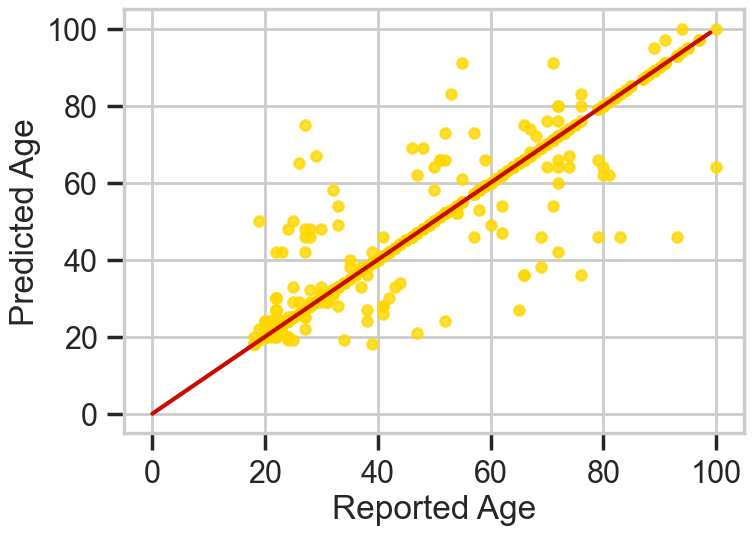

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('poster')

plt.scatter(X['Age'], predictions, color='gold', alpha=0.8, s=50)
plt.plot(range(100), range(100), color='r')
plt.xlabel('Reported Age')
plt.ylabel('Predicted Age')

In [14]:
# dt = regression.create_model('omp')
# regression.tune_model(dt, optimize='RMSE')
final_model = regression.finalize_model(dtree)
regression.save_experiment('hawkeye-hands-texture-fraction-dtree')

In [15]:
# saved_model = regression.load_model('hawkeye-hands-texture-fraction-dtree')

In [16]:
import shap
shap.initjs()

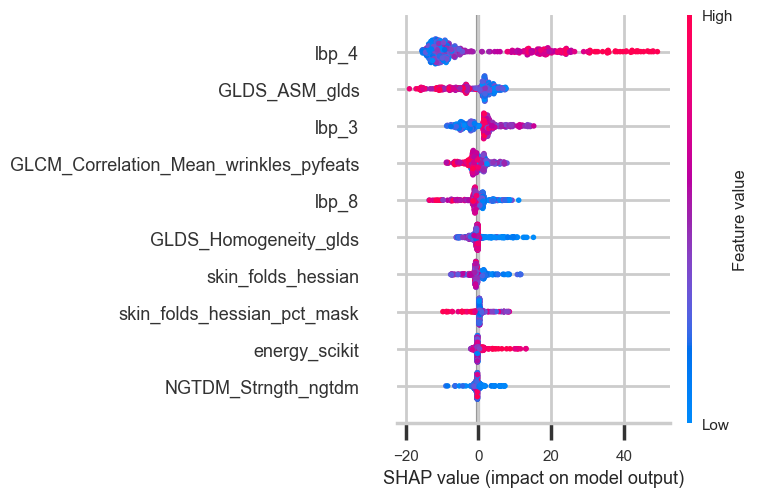

In [17]:
explainer = shap.Explainer(dtree)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values=shap_values, 
                  features=X, 
                  max_display=10)

### Model analysis

In [103]:
df = pd.read_csv('2024-08-01_NT_Hawkeye-Hands-Texture-Features.csv')
df = df.drop(columns=['Unnamed: 0',])
df.loc[:,'filename'] = df.loc[:,'filename'] + '.jpeg'
df = df[df['Age'] < 150]
df = df[df['Age'] > 3]
df.loc[:, 'Predicted Age'] = predictions

right_hands = metadata.drop(columns=['left_hand_image_file']).set_index('right_hand_image_file')
left_hands = metadata.drop(columns=['right_hand_image_file']).set_index('left_hand_image_file')
hand_metadata = pd.concat([left_hands, right_hands], keys=['left_hand_image_file', 'right_hand_image_file']).rename_axis(['hand_image_file','filename'])
hand_metadata = hand_metadata.reset_index()
hand_metadata.shape

# eda_metadata = pd.get_dummies(

#     hand_metadata[].set_index('filename')
#     )

eda = pd.concat(
    [
        hand_metadata.set_index('filename').drop(columns=['Age']), 
        df.set_index('filename')
     ], 
     join='inner',
       axis=1).reset_index(drop=True)


In [104]:
eda.to_csv('2025-01-27_Metadata_withFullFeatures.csv')

Text(0, 0.5, 'Predicted Age')

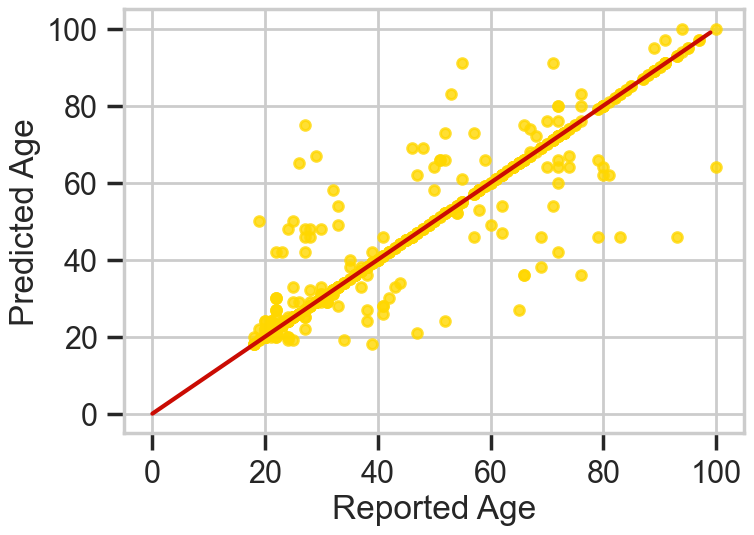

In [100]:
plt.scatter(eda['Age'], eda['Predicted Age'], color='gold', alpha=0.8, s=50)
plt.plot(range(100), range(100), color='r')
plt.xlabel('Reported Age')
plt.ylabel('Predicted Age')